In [14]:
import pickle
import sys
from pathlib import Path
import numpy as np
sys.path.append("..")

import pandas as pd



In [15]:
# ============================================================
# CONFIGURATION - Update this path to your data directory
# ============================================================

# DATA_DIR = Path('../pickle_files/data_30-01-2026_20-49-09')  # <-- One Hop. 
# DATA_DIR = Path('../pickle_files/data_30-01-2026_22-47-32')  # <-- Two Hop. 
DATA_DIR = Path('../pickle_files/data_30-01-2026_23-11-28')  # <-- Two + Three Hop.

MEASUREMENTS_FILE = DATA_DIR / 'measurements.pkl'
GRAPH_FILE = DATA_DIR / 'graph.pkl'
INFERRED_PARAMETERS_FILE = DATA_DIR / 'inferred_params_313.pkl'

# Verify files exist
print("Checking input files:")
for f in [MEASUREMENTS_FILE, GRAPH_FILE, INFERRED_PARAMETERS_FILE]:
    status = "✓" if f.exists() else "✗"
    print(f"  {status} {f.name}: {f.exists()}")

Checking input files:
  ✓ measurements.pkl: True
  ✓ graph.pkl: True
  ✓ inferred_params_313.pkl: True


In [16]:
class TimeAwareMeasurement:
    """Data class for syndrome measurements with timing information."""
    def __init__(self, path_edges, histogram, duration, latency_stats=None, code_type='513'):
        """
        :param path_edges: List of tuples representing the path, e.g., [(0,1), (1,2)]
        :param histogram: A numpy array of syndrome counts.
        :param duration: The duration or average latency of this measurement (seconds).
        :param latency_stats: A dictionary with 'max', 'std', 'count'.
        :param code_type: String indicating the code type, e.g., '313_X', '313_Z', '513'.
        """
        self.path_edges = path_edges
        self.histogram = histogram
        self.duration = duration
        self.latency_stats = latency_stats
        self.code_type = code_type

In [17]:
# ============================================================
# LOAD PICKLE FILES
# ============================================================

with open(MEASUREMENTS_FILE, 'rb') as f:
    measurements = pickle.load(f)

with open(GRAPH_FILE, 'rb') as f:
    graph = pickle.load(f)

with open(INFERRED_PARAMETERS_FILE, 'rb') as f:
    inferred_params = pickle.load(f)

print(f"Loaded {len(measurements)} syndrome measurements")
print(f"Loaded graph with {len(graph.nodes)} nodes and {len(graph.edges)} edges")
print(f"Loaded Inferred Parameters for {len(inferred_params)} edges")

Loaded 96 syndrome measurements
Loaded graph with 6 nodes and 7 edges
Loaded Inferred Parameters for 7 edges


In [18]:
# ============================================================
# DISPLAY INFERRED PARAMETERS (3-basis format: px, py, pz, pi)
# ============================================================

params_data = []
for edge, rates in inferred_params.items():
    e_z = rates.get('e_z', rates['px'] + rates['py'])  # bit flip rate
    e_x = rates.get('e_x', rates['py'] + rates['pz'])  # phase flip rate
    params_data.append({
        'Edge': str(edge),
        'px': rates['px'],
        'py': rates['py'],
        'pz': rates['pz'],
        'pi': rates['pi'],
        'e_z (X+Y)': e_z,
        'e_x (Y+Z)': e_x,
    })

df_params = pd.DataFrame(params_data)

styled_params = (df_params
    .style
    .format({col: '{:.4f}' for col in ['px', 'py', 'pz', 'pi', 'e_z (X+Y)', 'e_x (Y+Z)']})
    .set_caption('Inferred Parameters Summary (3-basis: px, py, pz, pi)')
    .background_gradient(subset=['e_z (X+Y)', 'e_x (Y+Z)'], cmap='YlOrRd', vmin=0, vmax=0.5)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#f5f5f5')]},
    ])
)

display(styled_params)

,Edge,px,py,pz,pi,e_z (X+Y),e_x (Y+Z)
0,"(0, 1)",0.0240,0.0232,0.0355,0.9174,0.0472,0.0586
1,"(0, 3)",0.0131,0.0314,0.0181,0.9374,0.0445,0.0495
2,"(1, 2)",0.0243,0.0162,0.0350,0.9245,0.0405,0.0512
3,"(1, 4)",0.0975,0.4024,0.0726,0.4275,0.4999,0.4750
4,"(3, 4)",0.0551,0.0125,0.0600,0.8724,0.0676,0.0725
5,"(2, 5)",0.0287,0.0068,0.0365,0.9280,0.0355,0.0433
6,"(4, 5)",0.0272,0.0294,0.0370,0.9064,0.0566,0.0663


In [19]:
# ============================================================
# DISPLAY SYNDROME MEASUREMENTS
# ============================================================

measurements_data = []
for measure in measurements:
    hist_norm = measure.histogram / np.sum(measure.histogram)
    measurements_data.append({
        'Path': str(measure.path_edges),
        'Code': measure.code_type,
        'P(00)': hist_norm[0],
        'P(01)': hist_norm[1],
        'P(10)': hist_norm[2],
        'P(11)': hist_norm[3],
    })

df_measurements = pd.DataFrame(measurements_data)

styled_measurements = (df_measurements
    .style
    .format({'P(00)': '{:.3f}', 'P(01)': '{:.3f}', 'P(10)': '{:.3f}', 'P(11)': '{:.3f}'})
    .set_caption(f'Syndrome Measurements Summary ({len(measurements)} total)')
    .background_gradient(subset=['P(00)'], cmap='Greens', vmin=0, vmax=1)
    .applymap(lambda x: 'color: #2e7d32; font-weight: bold' if x == '313_X' else 'color: #1565c0; font-weight: bold', subset=['Code'])
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
    ])
)

display(styled_measurements)

/var/folders/t2/g8j2h9dd5gj5c2454fz6jz980000gn/T/ipykernel_61028/756565496.py:24: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: 'color: #2e7d32; font-weight: bold' if x == '313_X' else 'color: #1565c0; font-weight: bold', subset=['Code'])


,Path,Code,P(00),P(01),P(10),P(11)
0,"[(0, 3), (3, 4), (4, 1)]",313_X,0.238,0.254,0.251,0.257
1,"[(0, 3), (3, 4), (4, 1)]",313_Z,0.254,0.248,0.250,0.248
2,"[(0, 1), (1, 2)]",313_X,0.755,0.087,0.091,0.067
3,"[(0, 1), (1, 2)]",313_Z,0.713,0.093,0.105,0.089
4,"[(0, 1), (1, 4), (4, 3)]",313_X,0.243,0.257,0.255,0.245
5,"[(0, 1), (1, 4), (4, 3)]",313_Z,0.263,0.245,0.253,0.238
6,"[(0, 3), (3, 4)]",313_X,0.706,0.120,0.095,0.080
7,"[(0, 3), (3, 4)]",313_Z,0.678,0.120,0.110,0.091
8,"[(0, 1), (1, 4)]",313_X,0.243,0.251,0.253,0.253
9,"[(0, 1), (1, 4)]",313_Z,0.244,0.258,0.246,0.252


In [20]:
bit_flip_syndromes = [m for m in measurements if m.code_type == '313_X']
phase_flip_syndromes = [m for m in measurements if m.code_type == '313_Z']

## Predict Syndrome Histograms from Inferred Params (Pauli Composition)

Given the Inferred Params Pauli error rates (px, py, pz) for each edge, we can predict the expected syndrome histogram for any path using proper **Pauli channel composition**.

**Pauli multiplication rules (ignoring phase):**
- I×I=I, X×X=I, Y×Y=I, Z×Z=I  
- I×X=X, X×I=X, Y×Z=X, Z×Y=X
- I×Y=Y, Y×I=Y, X×Z=Y, Z×X=Y
- I×Z=Z, Z×I=Z, X×Y=Z, Y×X=Z

**Syndrome mapping for [[3,1,3]] repetition code:**
- **313_X** (bit-flip detection): Z stabilizers detect X and Y errors; Z errors invisible
- **313_Z** (phase-flip detection): X stabilizers detect Z and Y errors; X errors invisible

In [21]:
# ============================================================
# PAULI COMPOSITION AND SYNDROME PREDICTION FUNCTIONS
# ============================================================
from typing import List, Tuple, Dict

def pauli_compose(state: np.ndarray, edge_probs: np.ndarray) -> np.ndarray:
    """
    Compose accumulated Pauli state with edge's Pauli channel.
    
    Pauli multiplication rules (ignoring phase):
    - I*I=I, X*X=I, Y*Y=I, Z*Z=I
    - I*X=X, X*I=X, Y*Z=X, Z*Y=X
    - I*Y=Y, Y*I=Y, X*Z=Y, Z*X=Y
    - I*Z=Z, Z*I=Z, X*Y=Z, Y*X=Z
    
    Args:
        state: [pI, pX, pY, pZ] accumulated Pauli distribution
        edge_probs: [pX, pY, pZ] edge error probabilities (pI computed as 1 - sum)
    
    Returns:
        New [pI, pX, pY, pZ] state after applying edge channel
    """
    pi, px, py, pz = state[0], state[1], state[2], state[3]
    e_px, e_py, e_pz = edge_probs[0], edge_probs[1], edge_probs[2]
    e_pi = 1.0 - e_px - e_py - e_pz
    
    # Apply Pauli composition rules
    new_pi = pi*e_pi + px*e_px + py*e_py + pz*e_pz
    new_px = pi*e_px + px*e_pi + py*e_pz + pz*e_py
    new_py = pi*e_py + py*e_pi + px*e_pz + pz*e_px
    new_pz = pi*e_pz + pz*e_pi + px*e_py + py*e_px
    
    return np.array([new_pi, new_px, new_py, new_pz])


def pauli_to_syndrome(state: np.ndarray, code_type: str = '313_X') -> np.ndarray:
    """
    Map Pauli state to 4D syndrome distribution.
    
    For [[3,1,3]] repetition code with 2 stabilizers:
    - 313_X (bit-flip detection): stabilizers Z1Z2, Z2Z3
      - Detects X and Y errors (bit flips)
      - Z errors are invisible
    - 313_Z (phase-flip detection): stabilizers X1X2, X2X3
      - Detects Z and Y errors (phase flips)
      - X errors are invisible
    
    Syndrome distribution for 3 i.i.d. qubits with flip probability p:
    - s_00: no flips (p_safe^3) + 3 flips (p_flip^3)
    - s_01, s_10, s_11: each = p_flip * p_safe
    
    Args:
        state: [pI, pX, pY, pZ] accumulated Pauli distribution
        code_type: '313_X' for bit-flip detection, '313_Z' for phase-flip detection
    
    Returns:
        [s_00, s_01, s_10, s_11] syndrome distribution
    """
    pi, px, py, pz = state[0], state[1], state[2], state[3]
    
    if code_type == '313_X':
        # Bit-flip detection: X and Y cause flips, I and Z are safe
        p_flip = px + py
        p_safe = pi + pz
    else:  # 313_Z
        # Phase-flip detection: Z and Y cause flips, I and X are safe
        p_flip = pz + py
        p_safe = pi + px
    
    # Syndrome probabilities
    s_00 = p_safe**3 + p_flip**3
    s_01 = p_flip * p_safe
    s_10 = s_01
    s_11 = s_01
    
    return np.array([s_00, s_01, s_10, s_11])


def get_edge_pauli_probs(edge: Tuple[int, int], ground_truth: Dict) -> np.ndarray:
    """
    Get Pauli error probabilities [px, py, pz] for an edge.
    
    Args:
        edge: Edge tuple (may need sorting)
        ground_truth: Ground truth dictionary with {edge: {'px', 'py', 'pz', 'pi'}}
    
    Returns:
        np.array([px, py, pz])
    """
    edge_key = tuple(sorted(edge))
    edge_data = ground_truth.get(edge_key)
    
    if edge_data is None:
        raise KeyError(f"No ground truth for edge {edge_key}")
    
    return np.array([edge_data['px'], edge_data['py'], edge_data['pz']])
    


def predict_syndrome_from_pauli(path_edges: List[Tuple[int, int]],
                                 ground_truth: Dict,
                                 code_type: str,
                                 num_shots: int = 4096) -> np.ndarray:
    """
    Predict syndrome histogram using proper Pauli channel composition.
    
    1. Start with identity state [1, 0, 0, 0] (no errors)
    2. Compose Pauli channels for each edge in the path
    3. Convert final Pauli state to syndrome distribution
    
    Args:
        path_edges: List of edge tuples in the path
        ground_truth: Dict mapping edge -> {px, py, pz, pi}
        code_type: '313_X' or '313_Z'
        num_shots: Number of shots for histogram scaling
    
    Returns:
        Predicted histogram [count_00, count_01, count_10, count_11]
    """
    # Start with identity (no error)
    state = np.array([1.0, 0.0, 0.0, 0.0])  # [pI, pX, pY, pZ]
    
    # Compose Pauli channels for each edge
    for edge in path_edges:
        edge_probs = get_edge_pauli_probs(edge, ground_truth)
        state = pauli_compose(state, edge_probs)
    
    # Convert to syndrome distribution
    syndrome_probs = pauli_to_syndrome(state, code_type)
    
    # Scale to histogram counts
    histogram = syndrome_probs * num_shots
    
    return histogram.astype(np.float32)


print("Pauli composition and syndrome prediction functions defined.")

Pauli composition and syndrome prediction functions defined.


In [22]:
# ============================================================
# COMPUTE PREDICTED VS OBSERVED SYNDROME HISTOGRAMS
# ============================================================

# Estimate num_shots from first measurement
NUM_SHOTS = int(np.sum(measurements[0].histogram))

comparison_results = []

for measurement in measurements:
    path_edges = measurement.path_edges
    code_type = measurement.code_type
    observed_hist = measurement.histogram
    
    # Predict histogram from ground truth using Pauli composition
    predicted_hist = predict_syndrome_from_pauli(
        path_edges=path_edges,
        ground_truth=inferred_params,
        code_type=code_type,
        num_shots=NUM_SHOTS
    )
    
    # Normalize both to probabilities
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    # Calculate accumulated Pauli state for this path
    state = np.array([1.0, 0.0, 0.0, 0.0])
    for edge in path_edges:
        edge_probs = get_edge_pauli_probs(edge, inferred_params)
        state = pauli_compose(state, edge_probs)
    
    comparison_results.append({
        'Path': str(path_edges),
        'Code': code_type,
        'pI': state[0],
        'pX': state[1],
        'pY': state[2],
        'pZ': state[3],
        'Pred P(00)': predicted_probs[0],
        'Obs P(00)': observed_probs[0],
        'Diff': observed_probs[0] - predicted_probs[0],
    })

df_pauli = pd.DataFrame(comparison_results)

# Style the DataFrame
def color_diff(val):
    """Color differences: green for small, red for large, text always black."""
    color = '#c8e6c9' if abs(val) < 0.02 else '#ffcdd2' if abs(val) > 0.05 else '#fff9c4'
    return f'background-color: {color}; color: black'

styled_pauli = (df_pauli
    .style
    .format({
        'pI': '{:.3f}', 'pX': '{:.3f}', 'pY': '{:.3f}', 'pZ': '{:.3f}',
        'Pred P(00)': '{:.4f}', 'Obs P(00)': '{:.4f}', 'Diff': '{:+.4f}'
    })
    .set_caption('Predicted vs Observed Syndrome Histograms (Pauli Composition Model)')
    .applymap(color_diff, subset=['Diff'])
    .background_gradient(subset=['Pred P(00)', 'Obs P(00)'], cmap='Blues', vmin=0, vmax=1)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '8px'), ('text-align', 'center')]},
    ])
)

display(styled_pauli)

/var/folders/t2/g8j2h9dd5gj5c2454fz6jz980000gn/T/ipykernel_61028/49604243.py:60: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(color_diff, subset=['Diff'])


,Path,Code,pI,pX,pY,pZ,Pred P(00),Obs P(00),Diff
0,"[(0, 3), (3, 4), (4, 1)]",313_X,0.379,0.141,0.359,0.121,0.2500,0.2380,-0.0120
1,"[(0, 3), (3, 4), (4, 1)]",313_Z,0.379,0.141,0.359,0.121,0.2511,0.2539,+0.0028
2,"[(0, 1), (1, 2)]",313_X,0.850,0.046,0.038,0.066,0.7696,0.7554,-0.0142
3,"[(0, 1), (1, 2)]",313_Z,0.850,0.046,0.038,0.066,0.7209,0.7126,-0.0083
4,"[(0, 1), (1, 4), (4, 3)]",313_X,0.371,0.148,0.352,0.129,0.2500,0.2427,-0.0073
5,"[(0, 1), (1, 4), (4, 3)]",313_Z,0.371,0.148,0.352,0.129,0.2511,0.2629,+0.0119
6,"[(0, 3), (3, 4)]",313_X,0.820,0.065,0.041,0.074,0.7155,0.7061,-0.0095
7,"[(0, 3), (3, 4)]",313_Z,0.820,0.065,0.041,0.074,0.6952,0.6782,-0.0170
8,"[(0, 1), (1, 4)]",313_X,0.406,0.116,0.384,0.094,0.2500,0.2429,-0.0071
9,"[(0, 1), (1, 4)]",313_Z,0.406,0.116,0.384,0.094,0.2515,0.2437,-0.0078


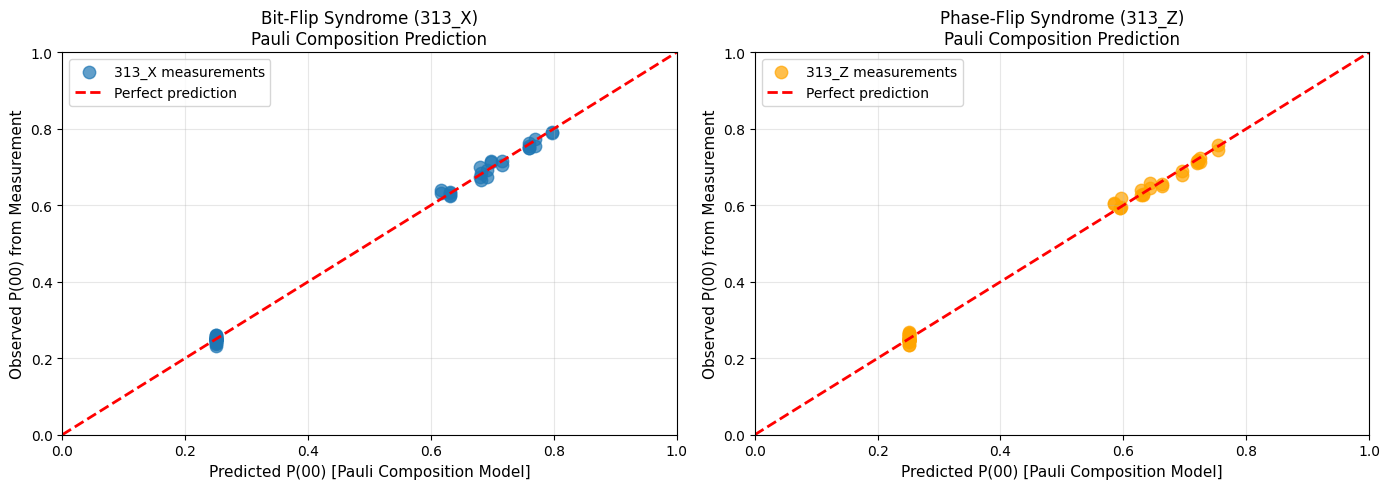

/var/folders/t2/g8j2h9dd5gj5c2454fz6jz980000gn/T/ipykernel_61028/515019596.py:67: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda x: f'background-color: {corr_color(x)}', subset=['Correlation (r)'])


,Syndrome,Correlation (r),Mean Diff,Std Diff
0,Bit-Flip (313_X),0.9992,-0.0004,0.0093
1,Phase-Flip (313_Z),0.9990,+0.0002,0.0097


In [23]:
# ============================================================
# VISUALIZE PAULI MODEL PREDICTIONS
# ============================================================
import matplotlib.pyplot as plt

df_bit_pauli = df_pauli[df_pauli['Code'] == '313_X']
df_phase_pauli = df_pauli[df_pauli['Code'] == '313_Z']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bit-flip syndrome
ax1 = axes[0]
ax1.scatter(df_bit_pauli['Pred P(00)'], df_bit_pauli['Obs P(00)'], 
            s=80, alpha=0.7, label='313_X measurements')
ax1.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel('Predicted P(00) [Pauli Composition Model]', fontsize=11)
ax1.set_ylabel('Observed P(00) from Measurement', fontsize=11)
ax1.set_title('Bit-Flip Syndrome (313_X)\nPauli Composition Prediction', fontsize=12)
ax1.legend()
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

# Plot 2: Phase-flip syndrome
ax2 = axes[1]
ax2.scatter(df_phase_pauli['Pred P(00)'], df_phase_pauli['Obs P(00)'], 
            s=80, alpha=0.7, color='orange', label='313_Z measurements')
ax2.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Perfect prediction')
ax2.set_xlabel('Predicted P(00) [Pauli Composition Model]', fontsize=11)
ax2.set_ylabel('Observed P(00) from Measurement', fontsize=11)
ax2.set_title('Phase-Flip Syndrome (313_Z)\nPauli Composition Prediction', fontsize=12)
ax2.legend()
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate correlation and display as styled table
corr_bit_pauli = np.corrcoef(df_bit_pauli['Pred P(00)'], df_bit_pauli['Obs P(00)'])[0, 1]
corr_phase_pauli = np.corrcoef(df_phase_pauli['Pred P(00)'], df_phase_pauli['Obs P(00)'])[0, 1]

summary_df = pd.DataFrame([
    {
        'Syndrome': 'Bit-Flip (313_X)',
        'Correlation (r)': corr_bit_pauli,
        'Mean Diff': df_bit_pauli['Diff'].mean(),
        'Std Diff': df_bit_pauli['Diff'].std(),
    },
    {
        'Syndrome': 'Phase-Flip (313_Z)',
        'Correlation (r)': corr_phase_pauli,
        'Mean Diff': df_phase_pauli['Diff'].mean(),
        'Std Diff': df_phase_pauli['Diff'].std(),
    }
])

def corr_color(val):
    """Color correlations: green for high, yellow for medium, red for low."""
    return '#c8e6c9' if val > 0.95 else '#fff9c4' if val > 0.8 else '#ffcdd2'

styled_summary = (summary_df
    .style
    .format({'Correlation (r)': '{:.4f}', 'Mean Diff': '{:+.4f}', 'Std Diff': '{:.4f}'})
    .set_caption('Pauli Composition Model Summary')
    .applymap(lambda x: f'background-color: {corr_color(x)}', subset=['Correlation (r)'])
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4a4a4a'), ('color', 'white'), ('padding', '10px'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('padding', '10px'), ('text-align', 'center')]},
    ])
)

display(styled_summary)

In [24]:
# ============================================================
# FULL HISTOGRAM COMPARISON (ALL 4 SYNDROME OUTCOMES)
# ============================================================

comparison_data = []

for measurement in measurements:
    path_edges = measurement.path_edges
    code_type = measurement.code_type
    observed_hist = measurement.histogram
    
    predicted_hist = predict_syndrome_from_pauli(
        path_edges=path_edges,
        ground_truth=inferred_params,
        code_type=code_type,
        num_shots=NUM_SHOTS
    )
    
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    comparison_data.append({
        'Path': str(path_edges),
        'Code': code_type,
        'Pred 00': predicted_probs[0],
        'Pred 01': predicted_probs[1],
        'Pred 10': predicted_probs[2],
        'Pred 11': predicted_probs[3],
        'Obs 00': observed_probs[0],
        'Obs 01': observed_probs[1],
        'Obs 10': observed_probs[2],
        'Obs 11': observed_probs[3],
    })

df_comparison = pd.DataFrame(comparison_data)

# Style the DataFrame for better readability
styled_df = (df_comparison
    .style
    .format({
        'Pred 00': '{:.3f}', 'Pred 01': '{:.3f}', 'Pred 10': '{:.3f}', 'Pred 11': '{:.3f}',
        'Obs 00': '{:.3f}', 'Obs 01': '{:.3f}', 'Obs 10': '{:.3f}', 'Obs 11': '{:.3f}',
    })
    .set_caption('Full Histogram Comparison: Predicted vs Observed')
    .background_gradient(subset=['Pred 00', 'Obs 00'], cmap='Blues', vmin=0, vmax=1)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]},
        {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px')]},
    ])
)

display(styled_df)

,Path,Code,Pred 00,Pred 01,Pred 10,Pred 11,Obs 00,Obs 01,Obs 10,Obs 11
0,"[(0, 3), (3, 4), (4, 1)]",313_X,0.250,0.250,0.250,0.250,0.238,0.254,0.251,0.257
1,"[(0, 3), (3, 4), (4, 1)]",313_Z,0.251,0.250,0.250,0.250,0.254,0.248,0.250,0.248
2,"[(0, 1), (1, 2)]",313_X,0.770,0.077,0.077,0.077,0.755,0.087,0.091,0.067
3,"[(0, 1), (1, 2)]",313_Z,0.721,0.093,0.093,0.093,0.713,0.093,0.105,0.089
4,"[(0, 1), (1, 4), (4, 3)]",313_X,0.250,0.250,0.250,0.250,0.243,0.257,0.255,0.245
5,"[(0, 1), (1, 4), (4, 3)]",313_Z,0.251,0.250,0.250,0.250,0.263,0.245,0.253,0.238
6,"[(0, 3), (3, 4)]",313_X,0.716,0.095,0.095,0.095,0.706,0.120,0.095,0.080
7,"[(0, 3), (3, 4)]",313_Z,0.695,0.102,0.102,0.102,0.678,0.120,0.110,0.091
8,"[(0, 1), (1, 4)]",313_X,0.250,0.250,0.250,0.250,0.243,0.251,0.253,0.253
9,"[(0, 1), (1, 4)]",313_Z,0.251,0.250,0.250,0.250,0.244,0.258,0.246,0.252


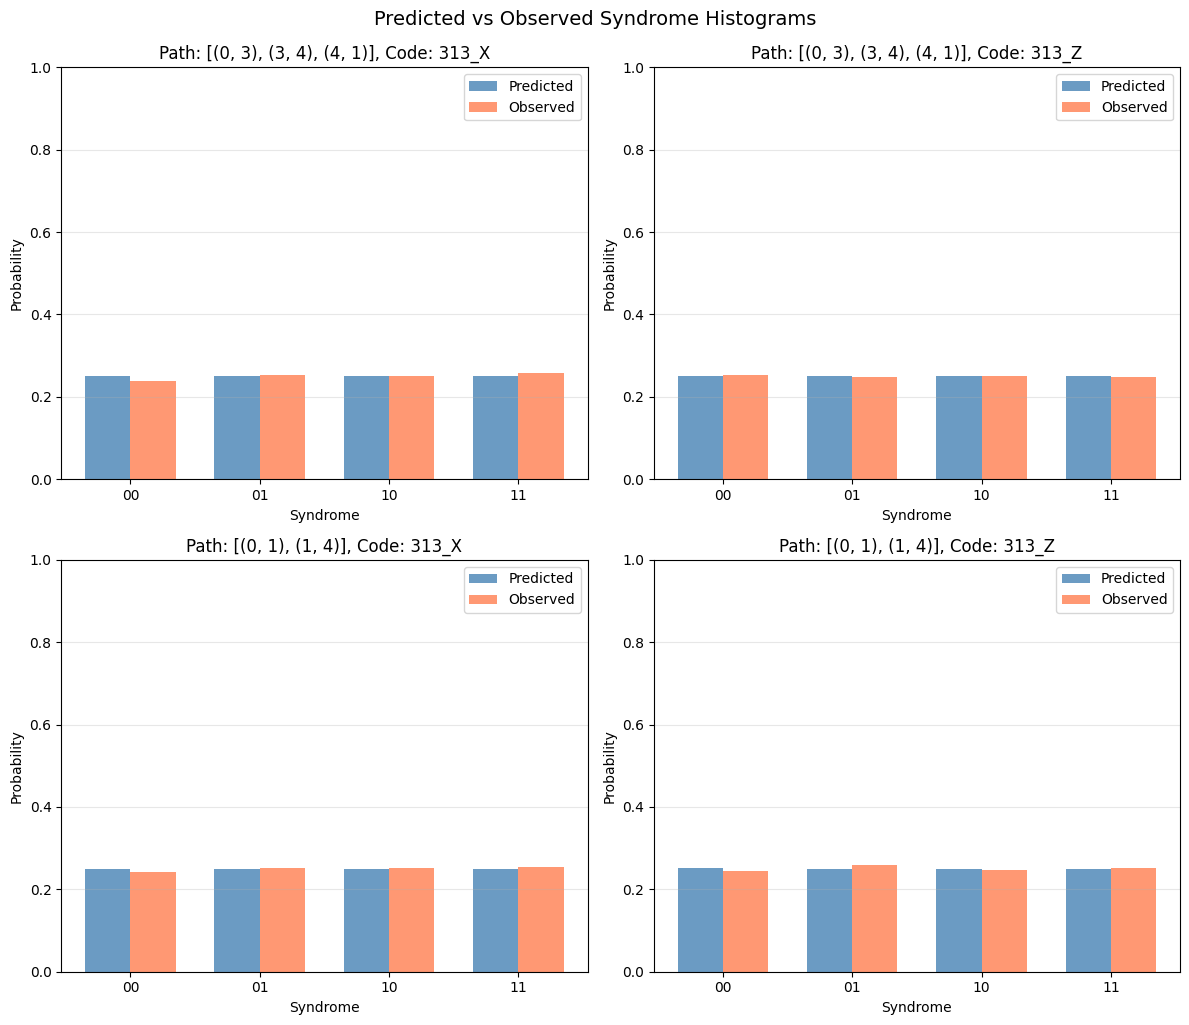

In [25]:
# ============================================================
# VISUAL HISTOGRAM COMPARISON FOR SELECTED PATHS
# ============================================================

# Select representative paths (first 4 measurements: 2 paths x 2 codes)
sample_indices = [0, 1, 8, 9] if len(measurements) > 9 else list(range(min(4, len(measurements))))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

syndrome_labels = ['00', '01', '10', '11']
x = np.arange(len(syndrome_labels))
width = 0.35

for i, idx in enumerate(sample_indices):
    if i >= len(axes):
        break
    ax = axes[i]
    measurement = measurements[idx]
    
    path_edges = measurement.path_edges
    code_type = measurement.code_type
    observed_hist = measurement.histogram
    
    predicted_hist = predict_syndrome_from_pauli(
        path_edges=path_edges,
        ground_truth=inferred_params,
        code_type=code_type,
        num_shots=NUM_SHOTS
    )
    
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    bars1 = ax.bar(x - width/2, predicted_probs, width, label='Predicted', color='steelblue', alpha=0.8)
    bars2 = ax.bar(x + width/2, observed_probs, width, label='Observed', color='coral', alpha=0.8)
    
    ax.set_xlabel('Syndrome')
    ax.set_ylabel('Probability')
    ax.set_title(f'Path: {path_edges}, Code: {code_type}')
    ax.set_xticks(x)
    ax.set_xticklabels(syndrome_labels)
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.suptitle('Predicted vs Observed Syndrome Histograms', fontsize=14, y=1.02)
plt.show()

In [26]:
# ============================================================
# OVERALL PREDICTION QUALITY METRICS
# ============================================================

def total_variation_distance(p, q):
    """Total Variation Distance: 0.5 * sum(|p_i - q_i|)"""
    return 0.5 * np.sum(np.abs(p - q))

def kl_divergence(p, q, epsilon=1e-10):
    """KL Divergence: sum(p * log(p/q))"""
    p = np.clip(p, epsilon, 1)
    q = np.clip(q, epsilon, 1)
    return np.sum(p * np.log(p / q))

metrics_bit = {'tvd': [], 'mse': [], 'kl': []}
metrics_phase = {'tvd': [], 'mse': [], 'kl': []}

for measurement in measurements:
    path_edges = measurement.path_edges
    code_type = measurement.code_type
    observed_hist = measurement.histogram
    
    predicted_hist = predict_syndrome_from_pauli(
        path_edges=path_edges,
        ground_truth=inferred_params,
        code_type=code_type,
        num_shots=NUM_SHOTS
    )
    
    observed_probs = observed_hist / np.sum(observed_hist)
    predicted_probs = predicted_hist / np.sum(predicted_hist)
    
    tvd = total_variation_distance(predicted_probs, observed_probs)
    mse = np.mean((predicted_probs - observed_probs)**2)
    kl = kl_divergence(observed_probs, predicted_probs)
    
    if code_type == '313_X':
        metrics_bit['tvd'].append(tvd)
        metrics_bit['mse'].append(mse)
        metrics_bit['kl'].append(kl)
    else:
        metrics_phase['tvd'].append(tvd)
        metrics_phase['mse'].append(mse)
        metrics_phase['kl'].append(kl)

print("="*70)
print("OVERALL PREDICTION QUALITY METRICS")
print("="*70)
print("\nBit-Flip Syndrome (313_X):")
print(f"  Mean TVD:  {np.mean(metrics_bit['tvd']):.4f} +/- {np.std(metrics_bit['tvd']):.4f}")
print(f"  Mean MSE:  {np.mean(metrics_bit['mse']):.6f} +/- {np.std(metrics_bit['mse']):.6f}")
print(f"  Mean KL:   {np.mean(metrics_bit['kl']):.4f} +/- {np.std(metrics_bit['kl']):.4f}")

print("\nPhase-Flip Syndrome (313_Z):")
print(f"  Mean TVD:  {np.mean(metrics_phase['tvd']):.4f} +/- {np.std(metrics_phase['tvd']):.4f}")
print(f"  Mean MSE:  {np.mean(metrics_phase['mse']):.6f} +/- {np.std(metrics_phase['mse']):.6f}")
print(f"  Mean KL:   {np.mean(metrics_phase['kl']):.4f} +/- {np.std(metrics_phase['kl']):.4f}")

print("\n" + "-"*70)
print("Interpretation:")
print("  TVD (Total Variation Distance): 0 = identical, 1 = completely different")
print("  MSE (Mean Squared Error): Lower is better")
print("  KL (KL Divergence): 0 = identical, higher = more different")

OVERALL PREDICTION QUALITY METRICS

Bit-Flip Syndrome (313_X):
  Mean TVD:  0.0158 +/- 0.0084
  Mean MSE:  0.000109 +/- 0.000112
  Mean KL:   0.0016 +/- 0.0019

Phase-Flip Syndrome (313_Z):
  Mean TVD:  0.0145 +/- 0.0066
  Mean MSE:  0.000084 +/- 0.000070
  Mean KL:   0.0011 +/- 0.0012

----------------------------------------------------------------------
Interpretation:
  TVD (Total Variation Distance): 0 = identical, 1 = completely different
  MSE (Mean Squared Error): Lower is better
  KL (KL Divergence): 0 = identical, higher = more different
